Let's implement the following models, all driven by 1-3 independent/correlated brownian motions. In the future, one of them will become fractional. 

(1) "The dynamics of stochastic volatility: evidence from underlying and options markets" - Jones, p.186: $W^1, W^2$ independent,

$$ \mathrm{d}S_t = \mu S_t \mathrm{d}t + \sqrt{V_t} S_t \mathrm{d}W^1_t, \qquad \mathrm{d}V_t = (\alpha + \beta V_t)\mathrm{d}t + \sigma_1 V_t^{\gamma_1} \mathrm{d}W^1_t + \sigma_2 V_t^{\gamma_2} \mathrm{d}W^2_t $$

(I guess without the drift in the equation for $S_t$)

(2) "The quadratic rough Heston model and the joint S&P 500/VIX smile calibration problem" - Gatheral, Jusselin, Rosenbaum, p.3-4 (non-Volterra version): $W^1$ and $W^2$ possibly correlated (actually not),

$$ \mathrm{d}S_t = S_t\sqrt{a(Z_t - b)^2 + c\,} \mathrm{d}W^1_t \qquad \mathrm{d}Z_t = \lambda (\theta(s) - Z_t)\mathrm{d}t + \lambda \eta \sqrt{a(Z_t - b)^2 + c\,} \mathrm{d} W^2_t $$

We will try to solve all equations in the way that is most similar to how they will be solved in the fractional case.


For later:

(3) "Fast Ninomiya-Victoir calibration of the Double-Mean-Reverting Model" - Bayer, Gatheral, Karlsmark, p.2: $W^1, W^2, W^3$ correlated $\mathrm{d}W^i_t \mathrm{d}W^j_t = \rho^{ij}\mathrm{d} t$,

$$ \mathrm{d} S_t = \sqrt{V_t} S_t \mathrm{d}W^1, \qquad \mathrm{d} v_t = \kappa_1 (V_t' - V_t)\mathrm{d}t + \xi_1 V_t^{\alpha_1} \mathrm{d}W^2_t, \qquad \mathrm{d} V'_t = \kappa_2 (\vartheta - V_t') \mathrm{d}t + \xi_2 V_t^{\alpha_2}\mathrm{d}W^3_t $$

(4) "Rough multifactor volatility for SPX and VIX options" - Jacquier, Muguruza, Pannier, p.4

$$ \mathrm{d} S_t = \sqrt{V_t} S_t \mathrm{d}W^1? \qquad V_t = V_0 \Big[\chi \exp \Big( \nu W^{2,H}_t + \frac{\nu^2}{2} t^{2H} \Big) + (1-\chi) \exp \Big( \eta W^{3,H}_t + \frac{\eta^2}{2} t^{2H} \Big) \Big] $$

What's the equation for $V$? It can be tested against the expression above.

In [2]:
# Imports
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffrax import *
from controls import *

In [53]:
# Global default parameters
t0, t1 = 0, 1
epsilon = 0.0001
lag = epsilon # = 1.2*epsilon was not really necessary
solver_epsilon = 0.01*epsilon # = 0.01*epsilon is really necessary in these examples
times = jnp.arange(t0, t1, epsilon)
num_samples = 5
dim_bm = 2

In [54]:
# (1) Dynamics of stoch vol. We want to solve this one without any correlation/lead-lag. Therefore we just use an Ito solver.

gamma1 = 1.2
gamma2 = 1.2 # note this is not Lipschitz and could explode...
sigma1 = 1.5
sigma2 = 1.5
alpha = 1.5
beta = 1.5


y0 = jnp.array([1, 1])
drift_jones = lambda t, y, args: jnp.array([0, alpha + beta*y[1]])
diffusion_jones = lambda t, y, args: jnp.array([[jnp.sqrt(y[1])*y[0], 0], [sigma1*jnp.power(y[1], gamma1), sigma2*jnp.power(y[1], gamma2)]])
saveat = SaveAt(ts = times)

In [55]:
key=jr.PRNGKey(512)
split_key = jax.random.split(key, num_samples)

solutions = vmap_batch_solve(split_key, epsilon, dim_bm, drift_jones, diffusion_jones, y0, Midpoint(), t0, t1, solver_epsilon, saveat)

In [56]:
# Let's check that using Euler instead of Midpoint as a solver does not change the solution (because time step of solver is finer than resolution of the data)
solutions_euler = vmap_batch_solve(split_key, epsilon, dim_bm, drift_jones, diffusion_jones, y0, Euler(), t0, t1, solver_epsilon, saveat)

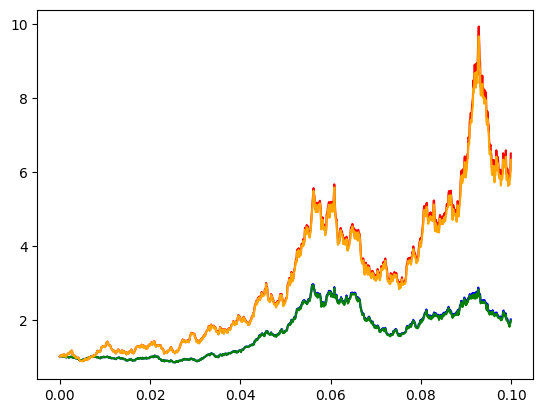

In [60]:
a, b = 0, 1000
path = 4
plt.plot(solutions.ts[path, a : b], solutions.ys[path, a : b, 0], color = "blue")
plt.plot(solutions.ts[path, a : b], solutions.ys[path, a : b, 1], color = "red")

plt.plot(solutions_euler.ts[path, a : b], solutions_euler.ys[path, a : b, 0], color = "green")
plt.plot(solutions_euler.ts[path, a : b], solutions_euler.ys[path, a : b, 1], color = "orange")

# The solutions are very close (when they don't explode), but only for the tested parameters. Actually epsilon = 0.001 has the same accuracy as epsilon = 0.0001.

This is actually the wrong solution, because it is Stratonovich. Let's write the original equation in Stratonovich form, solve it with our finer solver, and check that it agrees with the Ito solution.

$$ \mathrm{d}S_t = \sqrt{V_t} S_t \circ \mathrm{d}W^1_t - \frac 12  \bigg( V_t S_t \mathrm{d}[W^1]_t + \frac 12 \sigma_1 V_t^{\gamma_1-1/2} S_t \mathrm{d}[W^1]_t + \frac 12 \sigma_2 V_t^{\gamma_2-1/2} S_t \mathrm{d}[W^1, W^2]_t \bigg)$$

$$\mathrm{d}V_t = (\alpha + \beta V_t)\mathrm{d}t + \sigma_1 V_t^{\gamma_1} \circ \mathrm{d} W^1_t + \sigma_2 V_t^{\gamma_2} \circ \mathrm{d}W^2_t - \frac 12 \bigg( \sigma_1^2 \gamma_1 V_t^{2\gamma_1 - 1} \mathrm{d}[W^1]_t + \sigma_2^2 \gamma_2 V_t^{2\gamma_2 - 1} \mathrm{d}[W^2]_t + \sigma_1 \sigma_2 (\gamma_1 + \gamma_2) V_t^{\gamma_1 + \gamma_2 - 1} \mathrm{d}[W^1,W^2]_t \bigg)$$

We're taking $[W^1]_t = t = [W^2]_t$ and $[W^1,W^2] = 0$, so we have

$$ \mathrm{d}S_t = \sqrt{V_t} S_t \circ \mathrm{d}W^1_t - \frac 12  \bigg( V_t S_t + \frac 12 \sigma_1 V_t^{\gamma_1-1/2} S_t \bigg) \mathrm{d} t $$

$$\mathrm{d}V_t =  \sigma_1 V_t^{\gamma_1} \circ \mathrm{d} W^1_t + \sigma_2 V_t^{\gamma_2} \circ \mathrm{d}W^2_t + (\alpha + \beta V_t)\mathrm{d}t - \frac 12 \bigg( \sigma_1^2 \gamma_1 V_t^{\gamma_1 - 1}  + \sigma_2^2 \gamma_2 V_t^{\gamma_2 - 1} \bigg) \mathrm{d} t $$

Note that when we will take $W^2$ to be a fBm, $[W^2] = \infty$ and $[W^1,W^2] = \infty$ also if they are correlated, so these infinite terms cannot appear individually (they are absorbed in the lead-lag). 

In [32]:
#let's first simulate the Ito solution: this requires step size of solver equal to (or coarser) than step size of data

solver_epsilon = epsilon
solutions_true = vmap_batch_solve(split_key, epsilon, dim_bm, drift_jones, diffusion_jones, y0, Euler(), t0, t1, solver_epsilon, saveat)

In [33]:
# now let's check that it matches the Stratonovich solution with corrected drift, with finer step size of solver again

solver_epsilon = 0.01*epsilon
drift_jones_strat = lambda t, y, args: jnp.array([-(1/2)*(y[1]*y[0]+ (1/2)*sigma1*jnp.power(y[1], gamma1-1/2)*y[0]), alpha + beta*y[1] -(1/2) * ( jnp.power(sigma1,2)*gamma1*jnp.power(y[1], 2*gamma1-1) + jnp.power(sigma2,2)*gamma2*jnp.power(y[1], 2*gamma2-1) ) ])
diffusion_jones_strat = lambda t, y, args: jnp.array([[jnp.sqrt(y[1])*y[0], 0], [sigma1*jnp.power(y[1], gamma1), sigma2*jnp.power(y[1], gamma2)]])
solutions_strat = vmap_batch_solve(split_key, epsilon, dim_bm, drift_jones_strat, diffusion_jones_strat, y0, Midpoint(), t0, t1, solver_epsilon, saveat)

In [34]:
# Solution simulated in Strat form (with drift that makes it Ito) but with coarse solver

solver_epsilon = epsilon
solutions_strat_coarse = vmap_batch_solve(split_key, epsilon, dim_bm, drift_jones_strat, diffusion_jones_strat, y0, Midpoint(), t0, t1, solver_epsilon, saveat)

# Note how much faster the coarse solver is...

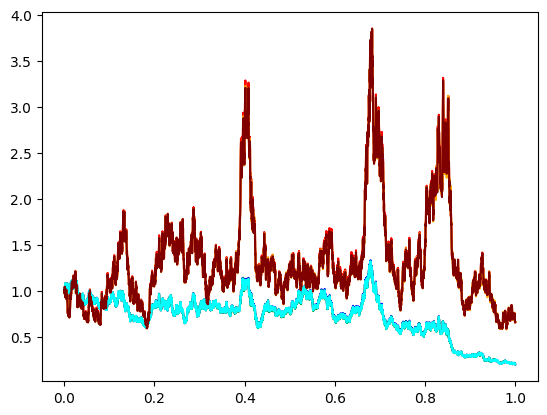

In [35]:
a, b = 0, 10000
path = 2
plt.plot(solutions_true.ts[path, a : b], solutions_true.ys[path, a : b, 0], color = "blue")
plt.plot(solutions_true.ts[path, a : b], solutions_true.ys[path, a : b, 1], color = "red")
plt.plot(solutions_strat.ts[path, a : b], solutions_strat.ys[path, a : b, 0], color = "green")
plt.plot(solutions_strat.ts[path, a : b], solutions_strat.ys[path, a : b, 1], color = "orange")
plt.plot(solutions_strat_coarse.ts[path, a : b], solutions_strat_coarse.ys[path, a : b, 0], color = "cyan")
plt.plot(solutions_strat_coarse.ts[path, a : b], solutions_strat_coarse.ys[path, a : b, 1], color = "maroon")

# They match
# Important reminder: when doing the fractional case, we will have to check that coarsening the solver does not change the solution. Here having epsilon = 0.0001 does help,
# although this could maybe be mitigated by using a more accurate solver

In [36]:
# Now let's solve them sequentially: first the volatility, then the price.

solver_epsilon = epsilon
y0 = jnp.array([1])
drift_jones_V = lambda t, y, args: jnp.array([alpha + beta*y[1] -(1/2) * ( jnp.power(sigma1,2)*gamma1*jnp.power(y[1], 2*gamma1-1) + jnp.power(sigma2,2)*gamma2*jnp.power(y[1], 2*gamma2-1) ) ])
diffusion_jones_V = lambda t, y, args: jnp.array([[sigma1*jnp.power(y[1], gamma1), sigma2*jnp.power(y[1], gamma2)]])
solutions_V = vmap_batch_solve(split_key, epsilon, dim_bm, drift_jones_V, diffusion_jones_V, y0, Midpoint(), t0, t1, solver_epsilon, saveat)
V = batch_sol_to_fun(solutions_V, num_samples)


y0 = jnp.array([1])
drift_jones_S = lambda t, y, args: jnp.array([0]) # Note we have put the Ito drift here
diffusion_jones_S = lambda t, y, k: jnp.array([[jnp.sqrt(V(t)[k])*y[0], 0]])
solutions_S = vmap_batch_solve_diff(split_key, epsilon, dim_bm, drift_jones_S, diffusion_jones_S, y0, Euler(), t0, t1, solver_epsilon, saveat)



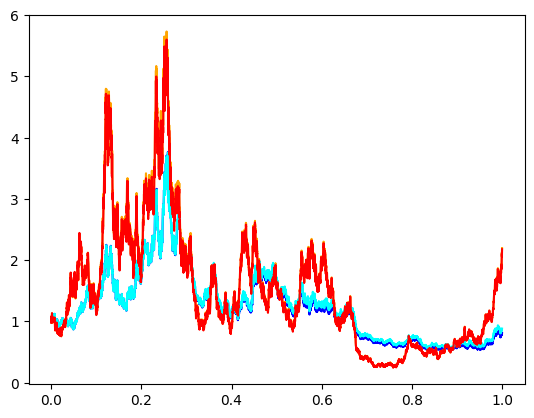

In [37]:
a, b = 0, 10000
path = 0

plt.plot(solutions_true.ts[path, a : b], solutions_true.ys[path, a : b, 0], color = "blue")
plt.plot(solutions_true.ts[path, a : b], solutions_true.ys[path, a : b, 1], color = "orange")
plt.plot(solutions_S.ts[path, a : b], solutions_S.ys[path, a : b, 1], color = "cyan")
plt.plot(solutions_V.ts[path, a : b], solutions_V.ys[path, a : b, 0], color = "red")

# Not perfect, but pretty good. The discrepancies can be attributed to the different solvers and time steps used. It is preferable to solve jointly, but this is a viable alternative in case
# the equation for the vol has to be done on a finer grid, in the fractional case. It also takes longer (but not as long as solving the vol on a fine grid).


An issue we will have when solving in the fractional case is that the equation for $V$ must be in Stratonovich form (Ito form is not defined for fBm). So we should always interpret the equation for $V$ in Stratonovich form. One can either correct with the drift that turns it back into Ito, or not; however, it is difficult to see what benefit this would have in the fractional case (where proving properties like mean reversion seems hard).

We can still insist that the equation for $S$ be a martingale though, by interpreting it in Ito form. To solve together with the second we will need to convert it to Strat form. The key point is that this can be done even in the fractional case, by only substracting the correction for $\mathrm{d}[W]$ but not for $\mathrm{d}[W,B^H]$ (absorbed into lead-lag).

For the quadratic rough Heston model, therefore, we will interpret the second equation in Strat form, with full correlation (so only one Bm):

$$ \mathrm{d}S_t = S_t\sqrt{a(Z_t - b)^2 + c\,} \mathrm{d}W_t \qquad \mathrm{d}Z_t = \lambda (\theta(s) - Z_t)\mathrm{d}t + \lambda \eta \sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d} W_t $$

Now, either we solve first $V$ and then $S$, or if we want to solve together we must convert the first to Strat form:

$$ \mathrm{d}S_t = S_t\sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d}W_t - \frac 12 S_t(a(Z_t - b)^2 + c) \mathrm{d}t \, {\color{orange} - \frac 12 a \lambda \eta S_t(Z_t - b) \mathrm{d}t} $$

The orange term must be present when simulating the whole thing with Strat, but must not be present when solving with lead-lag.

In [44]:
# (2) Quadratic rough Heston. Let's not batch solve for simplicity

a = 1
b = 0.5
c = 1
theta = 2
lam = 1
eta = 1

key=jr.PRNGKey(987)


# first we solve it with Stratonovich
dim_bm = 1
saveat = SaveAt(ts = times)
y0 = jnp.array([1, 1])
solver_epsilon = epsilon
vbt = VirtualBrownianTree(t0, t1+2*epsilon, tol=epsilon, shape=(dim_bm,), key=key)    
drift_qrh_strat = lambda t, y, args: jnp.array([-(1/2) * y[0] * ( a * jnp.square(y[1]-b) + c ) - (1/2) * a * lam * eta * y[0] * (y[1] - b) , lam*(theta - y[1])])
diffusion_qrh_strat = lambda t, y, args: jnp.array([[ y[0] * jnp.sqrt( a * jnp.square( y[1] - b )+ c ) ], [ lam * eta * jnp.sqrt( a * jnp.square( y[1] - b )+ c ) ]])
terms = MultiTerm(ODETerm(drift_qrh_strat), ControlTerm(diffusion_qrh_strat, vbt))
solutions_strat = diffeqsolve(terms, Midpoint(), t0, t1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)

In [45]:
# next, we solve it with the lead-lag control (this is the formulation that carries over to rough vol)
solver_epsilon = 0.01*epsilon # = 0.1*epsilon doesn't work too well; taking epsilon = 0.001 works ok but not as well as 0.0001
y0 = jnp.array([1, 1])

drift_qrh_ll = lambda t, y, args: jnp.array([-(1/2) * y[0] * ( a * jnp.square(y[1]-b) + c ), lam*(theta - y[1])])
diffusion_qrh_ll = lambda t, y, args: jnp.array([[ 0, y[0] * jnp.sqrt( a * jnp.square( y[1] - b )+ c ) ], [ lam * eta * jnp.sqrt( a * jnp.square( y[1] - b )+ c ), 0 ]])

# make the lead-lag control
bm_control = vbt.evaluate
lagged_bm_control = lagged_control(bm_control, lag)
lead_lag_control = join_controls(lagged_bm_control, bm_control)

terms = MultiTerm(ODETerm(drift_qrh_ll), ControlTerm(diffusion_qrh_ll, lead_lag_control))

solutions_ll = diffeqsolve(terms, Euler(), t0, t1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)


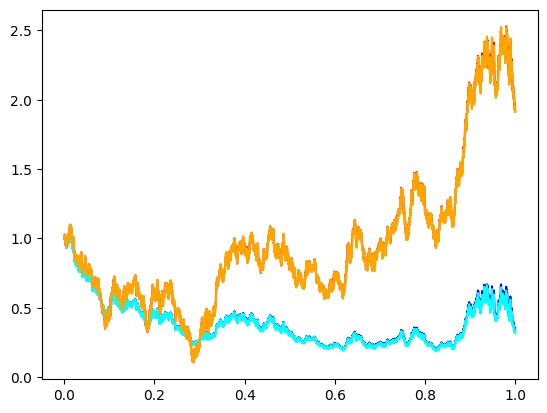

In [46]:
a, b = 0, 10000
plt.plot(solutions_strat.ts[a : b], solutions_strat.ys[a : b, 0], color = "blue")
plt.plot(solutions_strat.ts[a : b], solutions_strat.ys[a : b, 1], color = "red") # note this is Z, not actually the vol
plt.plot(solutions_ll.ts[a : b], solutions_ll.ys[a : b, 0], color = "cyan")
plt.plot(solutions_ll.ts[a : b], solutions_ll.ys[a : b, 1], color = "orange")

# They match